Moving Avg  -> MAE=104.22 RMSE=127.28 WAPE=0.753
Exponential Smoothing predictions: 3480
XGBoost     -> MAE=18.66 RMSE=27.38 WAPE=0.135


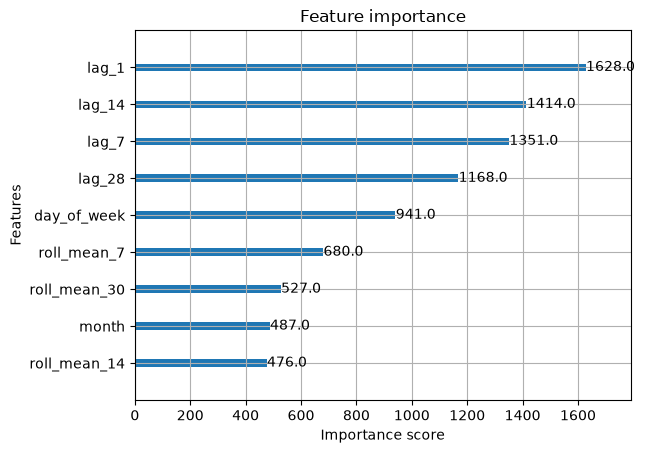

In [2]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

sales = pd.read_csv("../data/processed/fact_sales_clean.csv", parse_dates=["date"])
daily = sales.groupby(["date","product_id"])["quantity"].sum().reset_index()

# --- Feature engineering ---
daily = daily.sort_values(["product_id","date"])
for lag in [1,7,14,28]:
    daily[f"lag_{lag}"] = daily.groupby("product_id")["quantity"].shift(lag)
for w in [7,14,30]:
    daily[f"roll_mean_{w}"] = daily.groupby("product_id")["quantity"].shift(1).rolling(w).mean().reset_index(0,drop=True)
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily = daily.dropna()

# --- Train/test split (last 60 days = test) ---
cutoff = daily["date"].max() - pd.Timedelta(days=60)
train = daily[daily["date"] <= cutoff]
test = daily[daily["date"] > cutoff]

features = [c for c in daily.columns if c.startswith("lag_") or c.startswith("roll_") or c in ["day_of_week","month"]]
X_train, y_train = train[features], train["quantity"]
X_test, y_test = test[features], test["quantity"]

# --- Metrics ---
def mae(y, yhat): return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def wape(y, yhat): return np.sum(np.abs(y - yhat)) / np.sum(np.abs(y))

# Model 1: Moving average baseline
pred_ma = test["roll_mean_30"]
print("Moving Avg  ->", f"MAE={mae(y_test,pred_ma):.2f} RMSE={rmse(y_test,pred_ma):.2f} WAPE={wape(y_test,pred_ma):.3f}")

# Model 2: Exponential smoothing (per product)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

preds_es = []

for pid, grp in train.groupby("product_id"):
    model = SimpleExpSmoothing(
        grp["quantity"].values,
        initialization_method="estimated"
    ).fit(smoothing_level=0.3)

    n_test = len(test[test["product_id"] == pid])
    forecast = model.forecast(n_test)

    preds_es.extend(forecast)

print("Exponential Smoothing predictions:", len(preds_es))

# Model 3: XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
print("XGBoost     ->", f"MAE={mae(y_test,pred_xgb):.2f} RMSE={rmse(y_test,pred_xgb):.2f} WAPE={wape(y_test,pred_xgb):.3f}")

# Feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model); plt.show()

In [3]:
# Evaluate Exponential Smoothing properly

pred_es = pd.Series(index=test.index, dtype=float)

for pid, grp in train.groupby("product_id"):
    test_pid = test[test["product_id"] == pid]

    model = SimpleExpSmoothing(
        grp["quantity"].values,
        initialization_method="estimated"
    ).fit(smoothing_level=0.3)

    pred_es.loc[test_pid.index] = model.forecast(len(test_pid))

print(
    "Exponential Smoothing ->",
    f"MAE={mae(y_test, pred_es):.2f} "
    f"RMSE={rmse(y_test, pred_es):.2f} "
    f"WAPE={wape(y_test, pred_es):.3f}"
)

print("\nModel Comparison")
print("-" * 55)
print(f"Moving Average        WAPE = {wape(y_test, pred_ma):.3f}")
print(f"Exponential Smoothing WAPE = {wape(y_test, pred_es):.3f}")
print(f"XGBoost               WAPE = {wape(y_test, pred_xgb):.3f}")

Exponential Smoothing -> MAE=25.62 RMSE=37.98 WAPE=0.185

Model Comparison
-------------------------------------------------------
Moving Average        WAPE = 0.753
Exponential Smoothing WAPE = 0.185
XGBoost               WAPE = 0.135


In [4]:
baseline_wape = wape(y_test, pred_ma)
xgb_wape = wape(y_test, pred_xgb)

improvement = (baseline_wape - xgb_wape) / baseline_wape

print(f"Baseline WAPE: {baseline_wape:.3f}")
print(f"XGBoost WAPE:  {xgb_wape:.3f}")
print(f"Relative WAPE improvement: {improvement:.1%}")

# Save trained model
xgb_model.save_model("../models/demand_forecast_xgb.json")

print("Model saved successfully.")

Baseline WAPE: 0.753
XGBoost WAPE:  0.135
Relative WAPE improvement: 82.1%
Model saved successfully.
